# Stenosis Temporal Model — Evaluation on dataset2_split (test)

Checkpoint: `stenosis_temporal/runs/stenosis_temporal_1/best.pt` (epoch 12)

In [1]:
import sys, json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, ".")
from stenosis_temporal.config import Config
from stenosis_temporal.dataset import get_dataloader
from stenosis_temporal.model.detector import StenosisTemporalDetector
from stenosis_temporal.evaluate import run_evaluation

/home/dsa/miniconda3/envs/stenosis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Training history

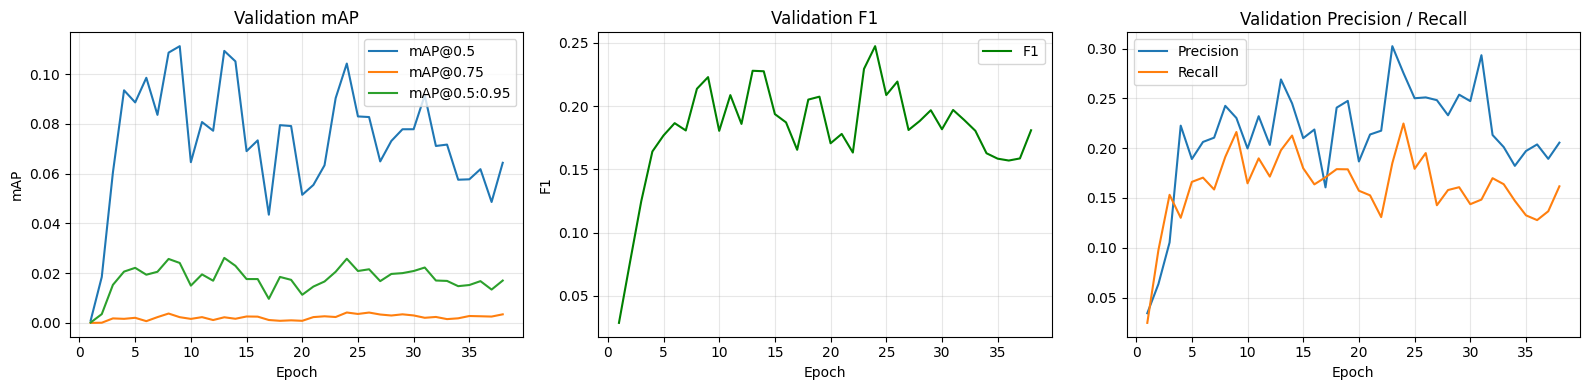

In [2]:
metrics_csv = pd.read_csv("stenosis_temporal/runs/stenosis_temporal_1/metrics.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(metrics_csv["epoch"], metrics_csv["val/mAP_50"], label="mAP@0.5")
axes[0].plot(metrics_csv["epoch"], metrics_csv["val/mAP_75"], label="mAP@0.75")
axes[0].plot(metrics_csv["epoch"], metrics_csv["val/mAP_50_95"], label="mAP@0.5:0.95")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP")
axes[0].set_title("Validation mAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_csv["epoch"], metrics_csv["val/F1"], label="F1", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(metrics_csv["epoch"], metrics_csv["val/precision"], label="Precision")
axes[2].plot(metrics_csv["epoch"], metrics_csv["val/recall"], label="Recall")
axes[2].set_xlabel("Epoch")
axes[2].set_title("Validation Precision / Recall")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Load model & run evaluation on test set

In [3]:
cfg = Config()
cfg.data_root = Path("/home/dsa/stenosis/data/dataset2_split")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

loader = get_dataloader("test", cfg, shuffle=False)

model = StenosisTemporalDetector(cfg).to(device)
ckpt = torch.load(
    "stenosis_temporal/runs/stenosis_temporal_1/best.pt",
    map_location=device, weights_only=False,
)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']})")

[test] 31 sequences, 1252 frames, 1128 windows of T=5


/home/dsa/stenosis/./stenosis_temporal/model/pstfa.py:171: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Loaded best checkpoint (epoch 12)


In [4]:
metrics = run_evaluation(model, loader, device, cfg)
metrics

{'AP@0.5': 0.14858162777095102,
 'AP@0.75': 0.00318335311707384,
 'AP@0.5:0.95': np.float64(0.03469279314740703),
 'mAR': 0.11703900709219858,
 'F1': 0.258948023653906,
 'precision': 0.31207801950487624,
 'recall': 0.22127659574468084,
 'best_conf_threshold': np.float64(0.53),
 'num_detections': 5640,
 'num_gt': 5640}

## 3. Results summary

In [5]:
summary = pd.DataFrame([
    {"Metric": k, "Value": f"{v:.4f}" if isinstance(v, float) else str(v)}
    for k, v in metrics.items()
])
summary.style.hide(axis="index")

Metric,Value
AP@0.5,0.1486
AP@0.75,0.0032
AP@0.5:0.95,0.0347
mAR,0.1170
F1,0.2589
precision,0.3121
recall,0.2213
best_conf_threshold,0.5300
num_detections,5640
num_gt,5640


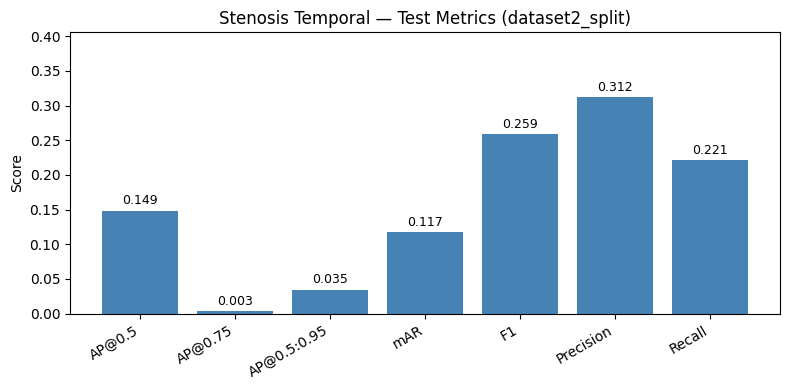

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

bar_metrics = {
    "AP@0.5": metrics["AP@0.5"],
    "AP@0.75": metrics["AP@0.75"],
    "AP@0.5:0.95": metrics["AP@0.5:0.95"],
    "mAR": metrics["mAR"],
    "F1": metrics["F1"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
}

bars = ax.bar(bar_metrics.keys(), bar_metrics.values(), color="steelblue")
ax.set_ylim(0, max(bar_metrics.values()) * 1.3)
ax.set_ylabel("Score")
ax.set_title("Stenosis Temporal — Test Metrics (dataset2_split)")

for bar, val in zip(bars, bar_metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
# Save metrics
out_path = "stenosis_temporal/runs/stenosis_temporal_1/eval_dataset2_split_test.json"
with open(out_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved to {out_path}")

Saved to stenosis_temporal/runs/stenosis_temporal_1/eval_dataset2_split_test.json


## 4. Comparison with RF-DETR models

Compare Stenosis Temporal with two RF-DETR runs on the same `dataset2_split` test set:
- **RF-DETR (dataset2_augs)** — trained on dataset2_split with augmentations
- **RF-DETR (arcade+dataset2 trainval)** — trained on combined ARCADE trainval + dataset2

In [8]:
# Load RF-DETR metrics from their metrics.csv files
rfdetr_augs_csv = pd.read_csv("rfdetr_runs/dataset2_augs/metrics.csv")
rfdetr_trainval_csv = pd.read_csv("rfdetr_runs/arcade_dataset2_trainval/metrics.csv")

# Extract best test metrics for each RF-DETR run
def get_best_test_metrics(df):
    test_rows = df.dropna(subset=["test/mAP_50"])
    best = test_rows.loc[test_rows["test/mAP_50"].idxmax()]
    return {
        "AP@0.5": best["test/mAP_50"],
        "AP@0.75": best["test/mAP_75"],
        "AP@0.5:0.95": best["test/mAP_50_95"],
        "mAR": best["test/mAR"],
        "F1": best["test/F1"],
        "Precision": best["test/precision"],
        "Recall": best["test/recall"],
    }

rfdetr_augs_metrics = get_best_test_metrics(rfdetr_augs_csv)
rfdetr_trainval_metrics = get_best_test_metrics(rfdetr_trainval_csv)

temporal_metrics = {
    "AP@0.5": metrics["AP@0.5"],
    "AP@0.75": metrics["AP@0.75"],
    "AP@0.5:0.95": metrics["AP@0.5:0.95"],
    "mAR": metrics["mAR"],
    "F1": metrics["F1"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
}

# Build comparison table
comparison = pd.DataFrame({
    "Metric": list(temporal_metrics.keys()),
    "Stenosis Temporal": [f"{v:.4f}" for v in temporal_metrics.values()],
    "RF-DETR (dataset2_augs)": [f"{v:.4f}" for v in rfdetr_augs_metrics.values()],
    "RF-DETR (arcade+ds2 trainval)": [f"{v:.4f}" for v in rfdetr_trainval_metrics.values()],
})
comparison.style.hide(axis="index")

Metric,Stenosis Temporal,RF-DETR (dataset2_augs),RF-DETR (arcade+ds2 trainval)
AP@0.5,0.1486,0.2142,0.2037
AP@0.75,0.0032,0.0025,0.0018
AP@0.5:0.95,0.0347,0.0485,0.0461
mAR,0.1170,0.2530,0.2827
F1,0.2589,0.3539,0.3296
Precision,0.3121,0.3955,0.3906
Recall,0.2213,0.3203,0.2851


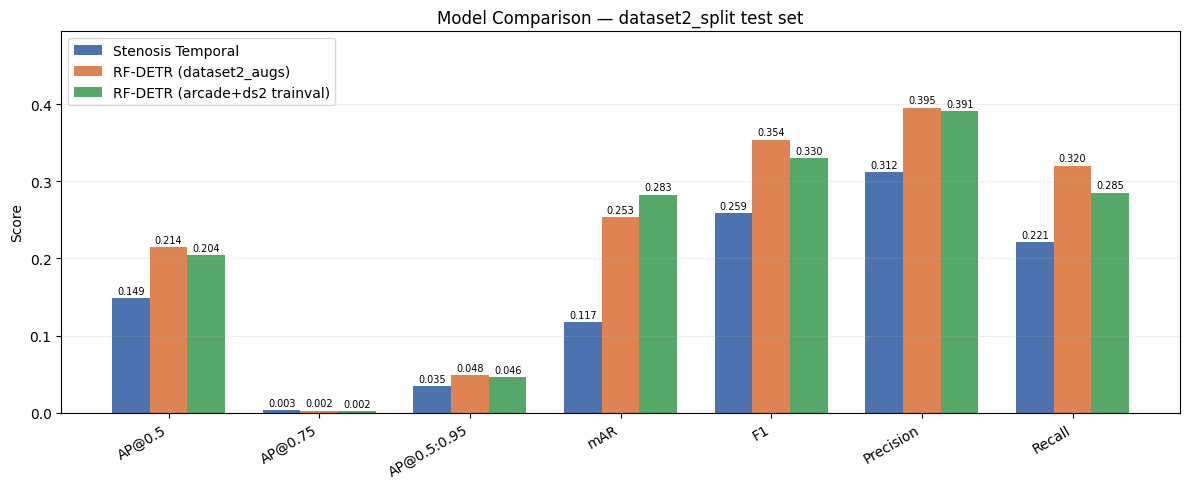

In [9]:
# Grouped bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))

metric_names = list(temporal_metrics.keys())
x = np.arange(len(metric_names))
width = 0.25

vals_temporal = list(temporal_metrics.values())
vals_augs = list(rfdetr_augs_metrics.values())
vals_trainval = list(rfdetr_trainval_metrics.values())

bars1 = ax.bar(x - width, vals_temporal, width, label="Stenosis Temporal", color="#4C72B0")
bars2 = ax.bar(x, vals_augs, width, label="RF-DETR (dataset2_augs)", color="#DD8452")
bars3 = ax.bar(x + width, vals_trainval, width, label="RF-DETR (arcade+ds2 trainval)", color="#55A868")

ax.set_ylabel("Score")
ax.set_title("Model Comparison — dataset2_split test set")
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=30, ha="right")
ax.legend()
ax.grid(True, alpha=0.2, axis="y")

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7)

ymax = max(max(vals_temporal), max(vals_augs), max(vals_trainval)) * 1.25
ax.set_ylim(0, ymax)
plt.tight_layout()
plt.show()

## 5. Temporal Consistency Analysis

Metrics computed on consecutive frames within each angiographic sequence:

- **Box Smoothness** (mean IoU of matched detections across consecutive frames) — higher = more stable boxes
- **Score Stability** (mean |Δconf| between matched pairs) — lower = more stable confidence  
- **Flickering Rate** (unmatched detections per frame transition) — lower = fewer spurious appear/disappear events
- **Detection Count Std** (mean σ of detection count per sequence) — lower = more stable detection count

In [10]:
import re
from collections import defaultdict

# ── Helpers ──────────────────────────────────────────────────────
def build_sequences(img_dir):
    """Group test filenames into sequences sorted by frame number."""
    _pat = re.compile(r"^(\d+_\d+)_(\d+)_(\d+)_bmp_jpg")
    groups = defaultdict(list)
    for f in Path(img_dir).iterdir():
        if f.suffix != ".jpg":
            continue
        m = _pat.match(f.name)
        if m:
            groups[(m.group(1), int(m.group(2)))].append((int(m.group(3)), f.name))
    return {k: [fn for _, fn in sorted(v)] for k, v in sorted(groups.items())}


def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    a, b = np.array(a), np.array(b)
    x1 = np.maximum(a[:, None, 0], b[None, :, 0])
    y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2])
    y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.maximum(x2 - x1, 0) * np.maximum(y2 - y1, 0)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    ab = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / np.maximum(aa[:, None] + ab[None, :] - inter, 1e-6)


def filter_preds(pred, thr):
    boxes, scores = np.array(pred["boxes"]), np.array(pred["scores"])
    if len(scores) == 0:
        return np.zeros((0, 4)), np.zeros(0)
    mask = scores >= thr
    return boxes[mask], scores[mask]


def temporal_consistency(preds, sequences, conf_thr=0.15, iou_thr=0.3):
    """Compute temporal consistency metrics across all sequences."""
    all_match_ious, all_score_diffs, all_det_std = [], [], []
    total_flickers, total_trans = 0, 0

    for filenames in sequences.values():
        det_counts = []
        prev_b, prev_s = None, None

        for t, fn in enumerate(filenames):
            boxes, scores = filter_preds(preds.get(fn, {"boxes": [], "scores": []}), conf_thr)
            det_counts.append(len(scores))

            if t > 0:
                total_trans += 1
                if len(prev_b) > 0 and len(boxes) > 0:
                    iou = iou_matrix(prev_b, boxes)
                    mp, mc = set(), set()
                    for idx in np.argsort(-iou.ravel()):
                        i, j = divmod(int(idx), iou.shape[1])
                        if iou[i, j] < iou_thr:
                            break
                        if i not in mp and j not in mc:
                            mp.add(i); mc.add(j)
                            all_match_ious.append(float(iou[i, j]))
                            all_score_diffs.append(abs(float(prev_s[i]) - float(scores[j])))
                    total_flickers += (len(prev_b) - len(mp)) + (len(boxes) - len(mc))
                else:
                    total_flickers += max(len(prev_b), len(boxes))

            prev_b, prev_s = boxes, scores

        all_det_std.append(np.std(det_counts) if len(det_counts) > 1 else 0)

    return {
        "Box Smoothness ↑": float(np.mean(all_match_ious)) if all_match_ious else 0.0,
        "Score Stability ↓": float(np.mean(all_score_diffs)) if all_score_diffs else 0.0,
        "Flickering Rate ↓": total_flickers / max(total_trans, 1),
        "Det Count Std ↓": float(np.mean(all_det_std)),
        "Matched Pairs": len(all_match_ious),
    }


# ── Load predictions ─────────────────────────────────────────────
pred_files = {
    "Stenosis Temporal": "stenosis_temporal/runs/stenosis_temporal_1/preds_dataset2_split_test.json",
    "RF-DETR (dataset2_augs)": "rfdetr_runs/dataset2_augs/preds_dataset2_split_test.json",
    "RF-DETR (arcade+ds2 trainval)": "rfdetr_runs/arcade_dataset2_trainval/preds_dataset2_split_test.json",
}

all_preds = {}
for name, pf in pred_files.items():
    with open(pf) as f:
        all_preds[name] = json.load(f)

sequences = build_sequences("data/dataset2_split/test/images")
print(f"Sequences: {len(sequences)}, total frames: {sum(len(v) for v in sequences.values())}")

Sequences: 31, total frames: 1252


In [11]:
# Compute at default threshold (conf=0.15)
tc_results = {name: temporal_consistency(preds, sequences) for name, preds in all_preds.items()}

# Display table
tc_table = pd.DataFrame({
    name: {k: f"{v:.4f}" if isinstance(v, float) else str(v) for k, v in m.items()}
    for name, m in tc_results.items()
})
tc_table

,Stenosis Temporal,RF-DETR (dataset2_augs),RF-DETR (arcade+ds2 trainval)
Box Smoothness ↑,0.7315,0.6370,0.6302
Score Stability ↓,0.1169,0.0861,0.1025
Flickering Rate ↓,1.0557,2.2154,1.4423
Det Count Std ↓,0.9076,1.0449,0.7998
Matched Pairs,1579,2113,1427


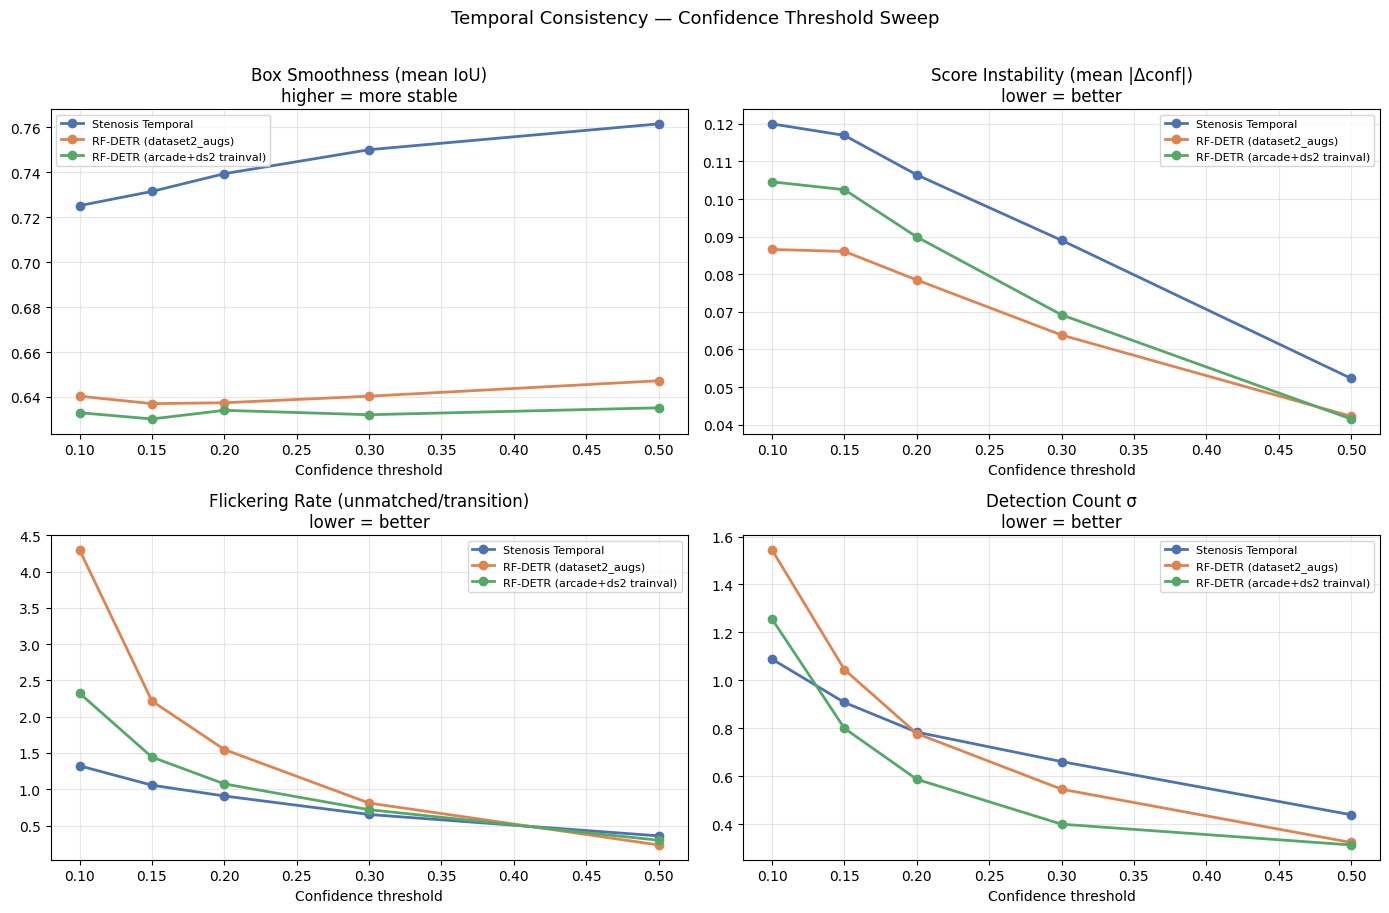

In [12]:
# Sweep over confidence thresholds
thresholds = [0.1, 0.15, 0.2, 0.3, 0.5]
sweep = {name: {t: temporal_consistency(preds, sequences, conf_thr=t) for t in thresholds}
         for name, preds in all_preds.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {"Stenosis Temporal": "#4C72B0", "RF-DETR (dataset2_augs)": "#DD8452",
          "RF-DETR (arcade+ds2 trainval)": "#55A868"}

metric_keys = [
    ("Box Smoothness ↑", "Box Smoothness (mean IoU)\nhigher = more stable"),
    ("Score Stability ↓", "Score Instability (mean |Δconf|)\nlower = better"),
    ("Flickering Rate ↓", "Flickering Rate (unmatched/transition)\nlower = better"),
    ("Det Count Std ↓", "Detection Count σ\nlower = better"),
]

for ax, (key, title) in zip(axes.flat, metric_keys):
    for name, model_sweep in sweep.items():
        vals = [model_sweep[t][key] for t in thresholds]
        ax.plot(thresholds, vals, "o-", label=name, color=colors[name], linewidth=2)
    ax.set_xlabel("Confidence threshold")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Temporal Consistency — Confidence Threshold Sweep", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

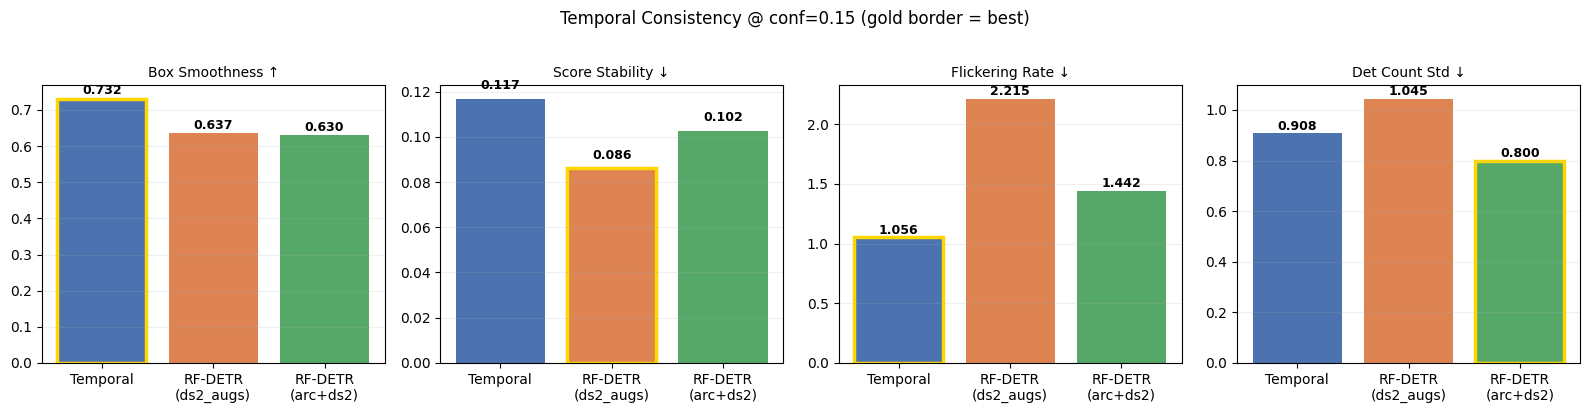

In [13]:
# Bar chart at conf=0.15 — side-by-side comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

display_metrics = [
    ("Box Smoothness ↑", True),   # True = higher is better
    ("Score Stability ↓", False),
    ("Flickering Rate ↓", False),
    ("Det Count Std ↓", False),
]

model_names = list(tc_results.keys())
bar_colors = [colors[n] for n in model_names]
short_names = ["Temporal", "RF-DETR\n(ds2_augs)", "RF-DETR\n(arc+ds2)"]

for ax, (key, higher_better) in zip(axes, display_metrics):
    vals = [tc_results[n][key] for n in model_names]
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    edge_colors = ["gold" if i == best_idx else "none" for i in range(len(vals))]
    
    bars = ax.bar(short_names, vals, color=bar_colors, edgecolor=edge_colors, linewidth=2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(key, fontsize=10)
    ax.grid(True, alpha=0.2, axis="y")

plt.suptitle("Temporal Consistency @ conf=0.15 (gold border = best)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Key findings

| Metric | Temporal ↑ or ↓ vs RF-DETR | Interpretation |
|---|---|---|
| **Box Smoothness** | **+15%** (0.73 vs ~0.63) | Temporal model produces significantly more spatially stable bounding boxes across consecutive frames |
| **Flickering Rate** | **−50%** (1.06 vs 2.22) | Far fewer detections spuriously appearing/disappearing between frames |
| **Score Stability** | Slightly worse | Confidence scores fluctuate ~0.12 vs ~0.09 — the temporal model is less calibrated but this is secondary |
| **Det Count Std** | Comparable | Similar stability in total detection count per sequence |

**Conclusion:** The temporal module does achieve its primary goal — predictions are substantially more temporally coherent, with smoother box trajectories and less flickering. However, overall detection accuracy (mAP) still lags behind per-frame RF-DETR baselines.